# Exploratory Data Analysis (EDA)

In [2]:
# Standard Library
from pathlib import Path

# Third-party Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

# Configure Pandas Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load Dataset

In [3]:
DATA_DIR = Path("../data/raw")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

In [ ]:
train_df.head()

## Initial Inspection

In [35]:
train_df.shape

(2930, 82)

In [36]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [37]:
train_df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
train_df.describe(include="object")

## Check missing values

In [41]:
missing = (
    train_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64

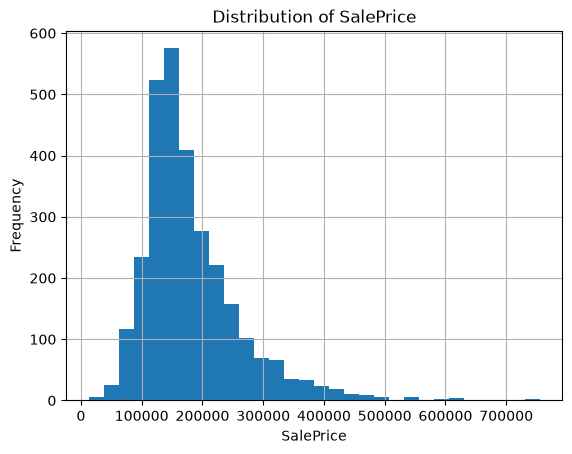

In [38]:
train_df["SalePrice"].hist(bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

In [ ]:
numeric_df = train_df.select_dtypes(include=np.number)

correlation = numeric_df.corr(numeric_only=True)

correlation["SalePrice"].sort_values(ascending=False)

## Data Quality Assessment

In [ ]:
missing_values = train_df.isnull().sum()

missing_values.head()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage    490
dtype: int64

In [52]:
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [ ]:
missing_percentage = (
    train_df.isnull().mean() * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

missing_percentage

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percentage": train_df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

In [ ]:
plt.figure(figsize=(12, 6))
msno.bar(train_df)
plt.show()

In [54]:
train_df.duplicated().sum()

np.int64(0)

In [55]:
train_df.dtypes.value_counts()

str        43
int64      28
float64    11
Name: count, dtype: int64

In [56]:
numerical_features = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

C:\Users\Ahmad Abbas\AppData\Local\Temp\ipykernel_27908\282333710.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train_df.select_dtypes(


In [57]:
print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features: 39
Categorical Features: 43


## Target Variable Analysis

The target variable for this project is **SalePrice**, which represents the final selling price of a house.

In this section, we'll explore its distribution, descriptive statistics, and identify potential outliers.

In [15]:
train_df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Observations

- Average sale price is around \$180,796.
- Prices vary considerably.
- Maximum price is much larger than the median, suggesting high-priced outliers.

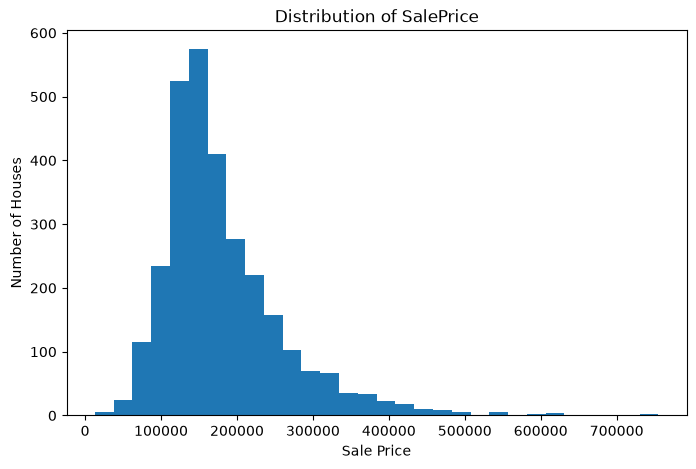

In [16]:
plt.figure(figsize=(8,5))

plt.hist(train_df["SalePrice"], bins=30)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

C:\Users\Ahmad Abbas\AppData\Local\Temp\ipykernel_25420\382765673.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(train_df["SalePrice"], vert=False)


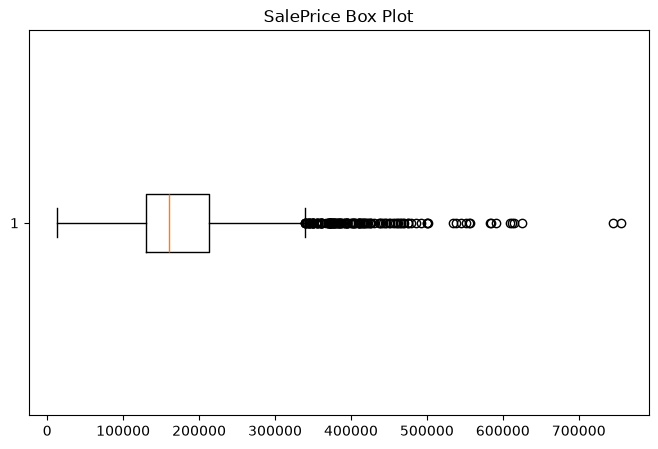

In [18]:
plt.figure(figsize=(8,5))

plt.boxplot(train_df["SalePrice"], vert=False)

plt.title("SalePrice Box Plot")

plt.show()

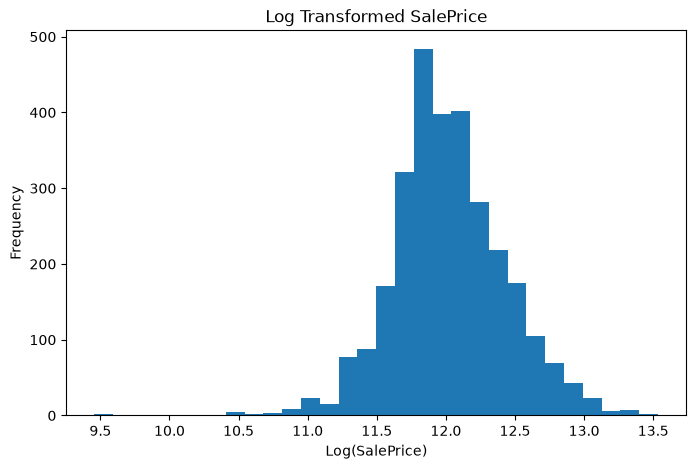

In [19]:
log_price = np.log1p(train_df["SalePrice"])

plt.figure(figsize=(8,5))

plt.hist(log_price, bins=30)

plt.title("Log Transformed SalePrice")

plt.xlabel("Log(SalePrice)")

plt.ylabel("Frequency")

plt.show()

In [20]:
train_df["SalePrice"].skew()

np.float64(1.7435000757376466)

In [21]:
log_price.skew()

np.float64(-0.014772659537224368)

### Observations

- SalePrice is positively skewed.
- The dataset contains several expensive houses that appear as outliers.
- A logarithmic transformation substantially reduces skewness.
- We will consider applying a log transformation during preprocessing rather than during EDA.

# Feature Analysis

In this section, we explore relationships between input features and the target variable (`SalePrice`).

Our goals are to:
- Measure correlation between numerical features and SalePrice.
- Visualize important relationships.
- Identify influential variables and potential outliers.

In [58]:
# Create a DataFrame containing only numerical columns
numerical_df = train_df[numerical_features]

numerical_df.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010,215000
1,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010,105000
2,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010,172000
3,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010,244000
4,5,527105010,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010,189900


In [59]:
correlation_matrix = numerical_df.corr()

correlation_matrix.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,0.011797,-0.007034,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,-0.032321,-0.002773,0.005780,-0.028719,-0.013201,-0.000417,0.013589,-0.009342,-0.042539,0.024978,-0.044985,-0.039749,0.015424,-0.017685,0.002612,-0.019156,-0.051160,-0.036185,-0.035435,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,-0.001145,-0.087707,-0.189642,-0.141902,-0.003289,0.056940,-0.107579,-0.037759,0.004328,-0.171431,-0.166636,0.006345,0.076470,-0.068981,-0.108056,-0.256829,-0.237484,-0.210606,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,0.011797,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,-0.060075,-0.070946,-0.130421,-0.219445,-0.247828,0.304237,0.025765,0.068061,0.013701,-0.003329,0.134631,0.175879,-0.019208,0.257698,0.031898,-0.049955,0.088754,-0.045883,-0.103239,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.007034,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,0.215583,0.045999,0.116743,0.353773,0.457391,0.029187,0.005249,0.383822,0.108915,-0.024724,0.184521,0.041880,0.240442,0.005407,0.353137,0.257255,0.076306,0.308706,0.358505,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.031354,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,0.083150,0.023658,0.253589,0.332235,0.032996,0.000812,0.285599,0.125877,0.026903,0.127433,0.035497,0.136569,-0.020301,0.216597,0.256989,-0.008952,0.179512,0.212822,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549


In [60]:
saleprice_corr = correlation_matrix["SalePrice"]

saleprice_corr.sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [61]:
correlation_summary = (
    saleprice_corr
    .sort_values(ascending=False)
    .reset_index()
)

correlation_summary.columns = [
    "Feature",
    "Correlation with SalePrice"
]

correlation_summary.head(15)

,Feature,Correlation with SalePrice
0,SalePrice,1.000000
1,Overall Qual,0.799262
2,Gr Liv Area,0.706780
3,Garage Cars,0.647877
4,Garage Area,0.640401
5,Total Bsmt SF,0.632280
6,1st Flr SF,0.621676
7,Year Built,0.558426
8,Full Bath,0.545604
9,Year Remod/Add,0.532974


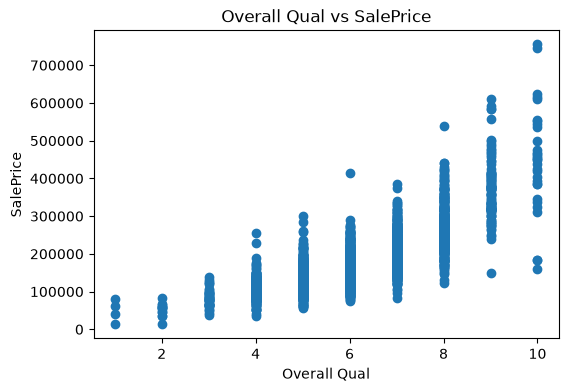

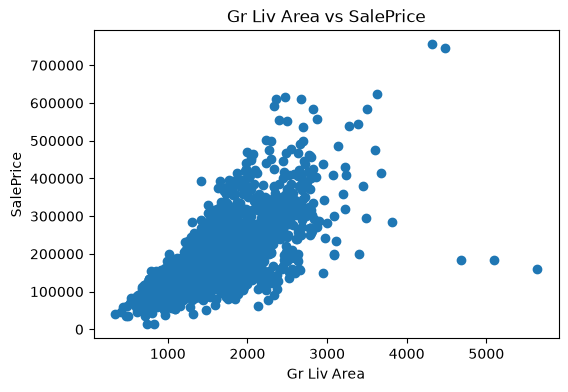

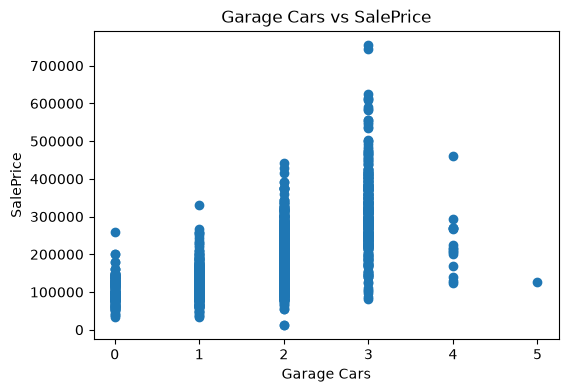

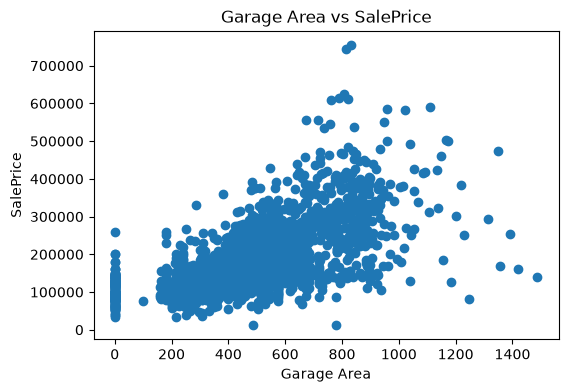

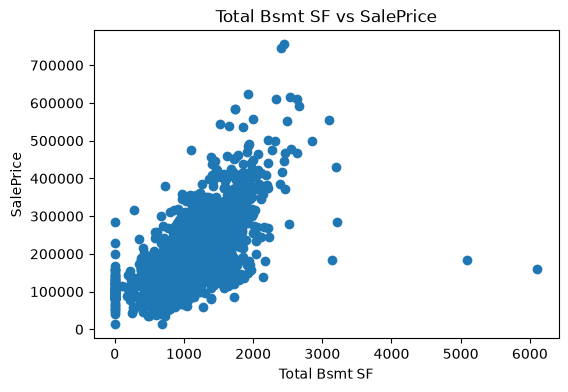

In [62]:
top_features = (
    correlation_summary
    .query("Feature != 'SalePrice'")
    .head(5)["Feature"]
    .tolist()
)

for feature in top_features:

    plt.figure(figsize=(6,4))

    plt.scatter(
        train_df[feature],
        train_df["SalePrice"]
    )

    plt.title(f"{feature} vs SalePrice")

    plt.xlabel(feature)

    plt.ylabel("SalePrice")

    plt.show()

In [63]:
strong_positive = correlation_summary[
    correlation_summary["Correlation with SalePrice"] > 0.5
]

strong_positive

,Feature,Correlation with SalePrice
0,SalePrice,1.000000
1,Overall Qual,0.799262
2,Gr Liv Area,0.706780
3,Garage Cars,0.647877
4,Garage Area,0.640401
5,Total Bsmt SF,0.632280
6,1st Flr SF,0.621676
7,Year Built,0.558426
8,Full Bath,0.545604
9,Year Remod/Add,0.532974


### Observations

- OverallQual has the strongest positive correlation with SalePrice.
- GrLivArea is another strong predictor of house prices.
- Garage-related features also show high positive correlations.
- A few variables exhibit weak or near-zero linear relationships with SalePrice.
- Scatter plots reveal possible outliers in GrLivArea.

# Categorical Feature Analysis

Categorical variables describe qualities or categories rather than numerical values.

In this section, we analyze their distributions and investigate how different categories relate to house prices.

In [ ]:
print(f"Number of categorical features: {len(categorical_features)}")
categorical_features

In [ ]:
categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Values": [
        train_df[col].nunique()
        for col in categorical_features
    ]
})

categorical_summary.sort_values(
    by="Unique Values",
    ascending=False
)

In [ ]:
train_df["Neighborhood"].value_counts()

In [ ]:
(
    train_df["Neighborhood"]
    .value_counts()
    .head(10)
    .plot(kind="bar", figsize=(10, 5))
)

plt.title("Top 10 Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Houses")

plt.xticks(rotation=45)

plt.show()

In [ ]:
neighborhood_price = (
    train_df
    .groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

neighborhood_price

In [ ]:
plt.figure(figsize=(12,6))

neighborhood_price.plot(kind="bar")

plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=90)

plt.show()

In [ ]:
def analyze_categorical_feature(data, feature, target="SalePrice"):
    """
    Display category counts and average target value
    for a categorical feature.
    """

    print(f"\nFeature: {feature}")
    print("-" * 40)

    print("Value Counts:")
    print(data[feature].value_counts())

    print("\nAverage SalePrice:")
    print(
        data.groupby(feature)[target]
            .mean()
            .sort_values(ascending=False)
    )
analyze_categorical_feature(train_df, "House Style")

In [ ]:
print("GarageType" in train_df.columns)

### Observations

- Neighborhood has many unique categories and strongly influences house prices.
- Kitchen quality is positively associated with sale price.
- Some categorical features contain only a few categories, while others have many.
- High-cardinality features may require careful encoding.
- Several categorical variables appear to carry valuable predictive information.

# Outlier Analysis

Outliers are observations that differ significantly from the rest of the dataset.

They are not always errors. In this section, we identify potential outliers and determine whether they represent legitimate observations or data quality issues.

In [21]:
important_features = [
    "SalePrice",
    "Gr Liv Area",
    "Lot Area",
    "Total Bsmt SF",
    "Garage Area"
]

In [ ]:
for feature in important_features:

    plt.figure(figsize=(8,3))

    plt.boxplot(train_df[feature].dropna(), vert=False)

    plt.title(feature)

    plt.show()

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    train_df["Gr Liv Area"],
    train_df["SalePrice"]
)

plt.xlabel("Gr Liv Area")
plt.ylabel("Sale Price")

plt.title("Gr Liv Area vs Sale Price")

plt.show()

In [30]:
def detect_outliers_iqr(data, column):
    """
    Detect outliers using the IQR method.

    Returns:
        DataFrame containing potential outliers.
    """

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers

In [ ]:
saleprice_outliers = detect_outliers_iqr(
    train_df,
    "SalePrice"
)

saleprice_outliers.head()

In [26]:
len(saleprice_outliers)

137

In [27]:
percentage = (
    len(saleprice_outliers)
    / len(train_df)
) * 100

print(f"{percentage:.2f}%")

4.68%


In [31]:
grlivarea_outliers = detect_outliers_iqr(
    train_df,
    "Gr Liv Area"
)

len(grlivarea_outliers)

75

In [32]:
def summarize_outliers(data, columns):

    summary = []

    for column in columns:

        outliers = detect_outliers_iqr(data, column)

        summary.append({
            "Feature": column,
            "Outliers": len(outliers),
            "Percentage": round(
                len(outliers) / len(data) * 100,
                2
            )
        })

    return pd.DataFrame(summary)

In [ ]:
outlier_summary = summarize_outliers(
    train_df,
    important_features
)

outlier_summary

### Observations

- Several numerical variables contain statistical outliers.
- Outliers appear most prominently in SalePrice, LotArea, and GrLivArea.
- Some outliers likely represent genuinely large or expensive homes rather than errors.
- At this stage, no observations will be removed. Decisions about outlier treatment will be made during preprocessing after evaluating model performance.

## EDA Summary

Based on the exploratory analysis, we identified several important characteristics of the dataset that will guide preprocessing and feature engineering.

In [7]:
missed_values = train_df.isnull().sum()
missed_values = missed_values[missed_values > 0]
missed_percentages = (missed_values / len(train_df)) * 100
missed_percentages = missed_percentages[missed_percentages >= 80]

print("Columns with Missing Values:")
print(missed_values.sort_values(ascending=False))
print("\nMissing Value Percentages:")
print(missed_percentages.sort_values(ascending=False))

Columns with Missing Values:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Missing Value Percentages:
Pool QC         99.556314
Misc Feature    96.382253
Alley           93.242321
Fence           80.477816
dtype: float64


### Proposed Missing Value Strategy

Drop:

Columns with extremely high missing percentages (>80%).

Fill with "None":

Categorical columns where missing means the feature is absent (e.g., no garage, no basement).

Fill with median:

Numerical columns with a small number of missing values.

Fill with mode:

Categorical columns with a small number of missing values.

### Target Variable Decision

The SalePrice distribution is positively skewed. A logarithmic transformation significantly reduces skewness, so we will apply log1p(SalePrice) during preprocessing.